### 研究不均匀载荷的作用，波浪空间不均匀的作用

In [2]:
#import packages
import time
import numpy as np
import capytaine as cpt
import scipy
from capytaine.io.mesh_writers import write_STL
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.linalg import eigh
import vtk
import logging
import xarray as xr
from capytaine.io.xarray import merge_complex_values
from capytaine.post_pro import rao
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s: %(message)s')
# user defined functions
import DM_ShowNodes as DMshow
import DM_Reading as dm_r
import DM_Assemble as DM_A
import SEREP as SEREP
import DM_Method as DM_M

## 具体实现的步骤和思路
### 1.读取不同方向及海况下的数据
### 2.重合整合数据集中的波浪载荷、将多组不同区域的载荷耦合到一个数据集中
### 3.将这个耦合的数据集输入到DM_M函数中计算。
### 总结：建立一个函数，处理多个数据集中的波浪载荷信息。

### 1. 实现Wei et al工作

In [3]:
# setting initial parameter, wind and wave conditions
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
master_nodes_length = len(master_nodes)
dataset_55 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction55_full40.nc"))
dataset_70 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction70_full40.nc"))
dataset_90 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\BM10_direaction90_full40.nc"))
file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_STIF1.mtx' 
wind_speed = 50
wind_direction = 0 # 风向角
Hs = 2.75          #Hs = np.array([1., 2., 3., 4., 5., 6.])
                #Tp = np.array([4.57, 6.46, 7.91, 9.13, 10.21, 11.18])
Tp = 7.78
distance = 30 # 模块之间的距离
F_wave_coifficient = 1 # 系数1代表考虑，0代表不考虑
F_wind_coifficient = 0
F_wind_damping = 0

interest_dof = 0 # dof 0:x 1:y 2:z
df = 0.01 # frequency resolution
use_hydrostatic = True # select hydrostatic stiffness type(bem or fem)
use_mooring = False 

In [4]:
dataset_55['excitation_force'] = dataset_55['Froude_Krylov_force'] + dataset_55['diffraction_force']
dataset_70['excitation_force'] = dataset_70['Froude_Krylov_force'] + dataset_70['diffraction_force']
dataset_90['excitation_force'] = dataset_90['Froude_Krylov_force'] + dataset_90['diffraction_force']

### 将连续结构划分为三个区域，3、4、3配置。

In [5]:
# 提取相应的部分
part1 = dataset_55['excitation_force'][:, 0, 0:18].values
part2 = dataset_90['excitation_force'][:, 0, 18:42].values  
part3 = dataset_70['excitation_force'][:, 0, 42:60].values  
new_excitation_force = np.concatenate((part1, part2, part3), axis=1).reshape(40,1,60)
new_excitation_force_da = xr.DataArray(new_excitation_force, dims=('omega', 'wave_direction','influenced_dof'))
dataset = dataset_55.copy()
dataset['excitation_force'] = new_excitation_force_da

In [6]:
def create_mooring_stiffness_matrix(stiffness_value):
    # 创建一个总的刚度矩阵，维度为 (total_nodes*6, total_nodes*6)
    total_nodes = 793
    total_dof = total_nodes * 5
    global_stiffness_matrix = np.zeros((total_dof, total_dof))
    
    # 确定四个角点的节点编号
    node1 = 1
    node2 = 61
    node3 = 733
    node4 = 793
    
    # 四个系泊点的节点列表
    mooring_nodes = [node1, node2, node3, node4]
    
    # 定义6x6的局部刚度矩阵
    local_stiffness_matrix = np.zeros((5, 5))
    local_stiffness_matrix[0, 0] = stiffness_value  # x方向刚度
    local_stiffness_matrix[1, 1] = stiffness_value  # y方向刚度
    
    # 将局部刚度矩阵插入到总的刚度矩阵中
    for node in mooring_nodes:
        start_index = (node - 1) * 5
        for i in range(5):  # 只处理前5个自由度
            for j in range(5):
                global_stiffness_matrix[start_index + i, start_index + j] = local_stiffness_matrix[i, j]
    
    return global_stiffness_matrix

In [7]:

def process_dataset(dataset, omega_number, M, k, num_nodes, master_nodes, use_mooring=False, use_hydrostatic=True, F_wave_coefficient=1.0):
    # reduce dofs
    M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    
    if use_mooring:
        k = SEREP.reduce_dofs(k, num_nodes, [5]) + create_mooring_stiffness_matrix(stiffness_value=1e6)
    else:
        k = SEREP.reduce_dofs(k, num_nodes, [5])
    
    # transform mass matrix, beta=0 is consistant mass matrix
    M = SEREP.transform_mass_matrix(M_consistant, beta=0)
    
    # obtain master dofs and slave dofs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)
    
    # reduce matrix use SEREP
    MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
    
    displacement = []
    F_wave = []
    mass_full = []
    damping_full = []
    stiffness_full = []
    
    for i in omega_number:
        # read hydrodynamic data
        added_mass = dataset['added_mass'][i].values
        radiation_damping = dataset['radiation_damping'][i].values
        F_w = dataset['excitation_force'][i].values
        
        # reduce matrices
        added_mass = SEREP.reduce_dofs(added_mass, len(master_nodes), [5])
        radiation_damping = SEREP.reduce_dofs(radiation_damping, len(master_nodes), [5])
        
        if use_hydrostatic:
            hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, len(master_nodes), [5])
            stiffness = hydrostatic_stiffness + KR
        else:
            total_nodes = 793
            nodes_per_row = 61
            area = 5 * 5
            k_fem = SEREP.get_fem_spring_stiffness(total_nodes, nodes_per_row, area)
            k_fem = SEREP.reduce_dofs(k_fem, num_nodes, [5])
            stiffness = T.T @ k_fem @ T + KR
        
        F_w = SEREP.reduce_force_matrix_dofs(F_w, len(master_nodes), 5).reshape(1, 5 * len(master_nodes))
        
        # generate the system matrices
        mass = added_mass + MR
        damping = radiation_damping
        total_force = F_w * F_wave_coefficient
        
        # solve in frequency domain
        master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, total_force, omega[i])
        
        # restore global displacement under disorder masterdofs and slavedofs
        global_displacement_disorder = T @ master_displacement
        
        # reorder global displacement under order
        global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
        
        # replace master with global displacement
        global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement, master_nodes)
        
        # save data
        displacement.append(global_displacement_replace)
        F_wave.append(F_w)
        mass_full.append(mass)
        damping_full.append(damping)
        stiffness_full.append(stiffness)
    
    return {
        'displacement': displacement,
        'F_wave': F_wave,
        'mass_full': mass_full,
        'damping_full': damping_full,
        'stiffness_full': stiffness_full
    }

# 主程序
omega = dataset_55.omega.values
omega_number = np.arange(0, 40, 1)

# 读取质量和刚度矩阵
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# 参数
num_nodes = 793
master_nodes = master_nodes = DM_A.calculate_node_positions(424,6,10)  # 示例主自由度节点
use_mooring = False
use_hydrostatic = True
F_wave_coefficient = 1.0

# 处理每个数据集
results_55 = process_dataset(dataset_55, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_70 = process_dataset(dataset_70, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_90 = process_dataset(dataset_90, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_combined = process_dataset(dataset, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)

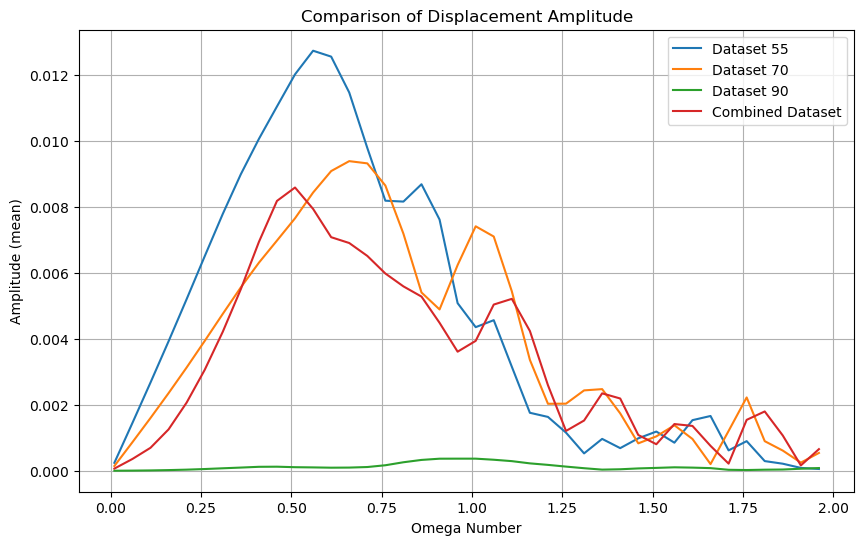

In [8]:
# 转换displacement数据结构为(40, 793, 5)
def reshape_displacement(displacement):
    num_omega, num_values, _ = displacement.shape
    num_nodes = 793
    dofs_per_node = 5
    reshaped_displacement = displacement.reshape(num_omega, num_nodes, dofs_per_node)
    return reshaped_displacement


# 获取数据
displacement_55 = np.array(results_55['displacement'])
displacement_70 = np.array(results_70['displacement'])
displacement_90 = np.array(results_90['displacement'])
displacement_combined = np.array(results_combined['displacement'])

# 重新调整数据结构
reshaped_displacement_55 = reshape_displacement(displacement_55)
reshaped_displacement_70 = reshape_displacement(displacement_70)
reshaped_displacement_90 = reshape_displacement(displacement_90)
reshaped_displacement_combined = reshape_displacement(displacement_combined)



# 绘制对比图
n = 381 # 366
DOF = 4
plt.figure(figsize=(10, 6))
plt.plot(omega, abs(reshaped_displacement_55[:,n,DOF]), label='Dataset 55')
plt.plot(omega, abs(reshaped_displacement_70[:,n,DOF]), label='Dataset 70')
plt.plot(omega, abs(reshaped_displacement_90[:,n,DOF]), label='Dataset 90')
plt.plot(omega, abs(reshaped_displacement_combined[:,n,DOF]), label='Combined Dataset')
plt.xlabel('Omega Number')
plt.ylabel('Amplitude (mean)')
plt.title('Comparison of Displacement Amplitude')
plt.legend()
# plt.ylim(0, 2)
plt.grid(True)
plt.show()


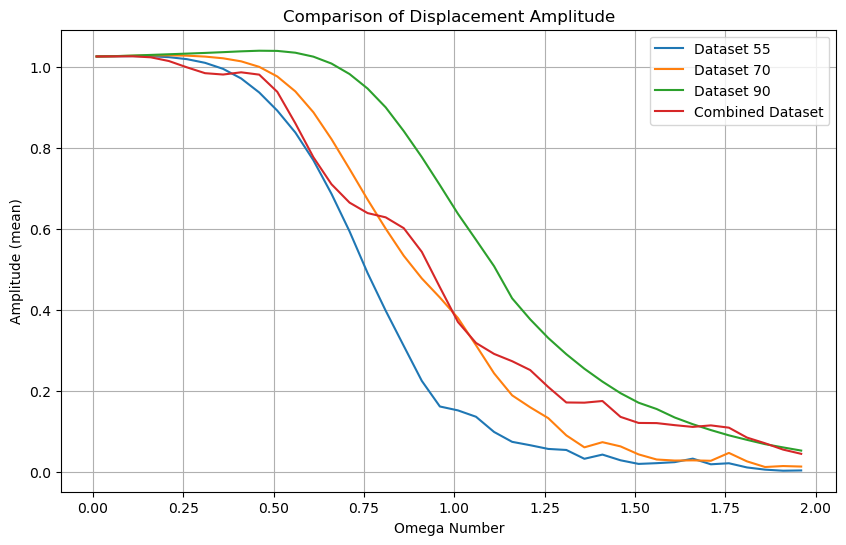

In [9]:
# 绘制对比图

plt.figure(figsize=(10, 6))
plt.plot(omega, abs(reshaped_displacement_55[:,:,2]).mean(axis=1), label='Dataset 55')
plt.plot(omega, abs(reshaped_displacement_70[:,:,2]).mean(axis=1), label='Dataset 70')
plt.plot(omega, abs(reshaped_displacement_90[:,:,2]).mean(axis=1), label='Dataset 90')
plt.plot(omega, abs(reshaped_displacement_combined[:,:,2]).mean(axis=1), label='Combined Dataset')
plt.xlabel('Omega Number')
plt.ylabel('Amplitude (mean)')
plt.title('Comparison of Displacement Amplitude')
plt.legend()
plt.grid(True)
plt.show()

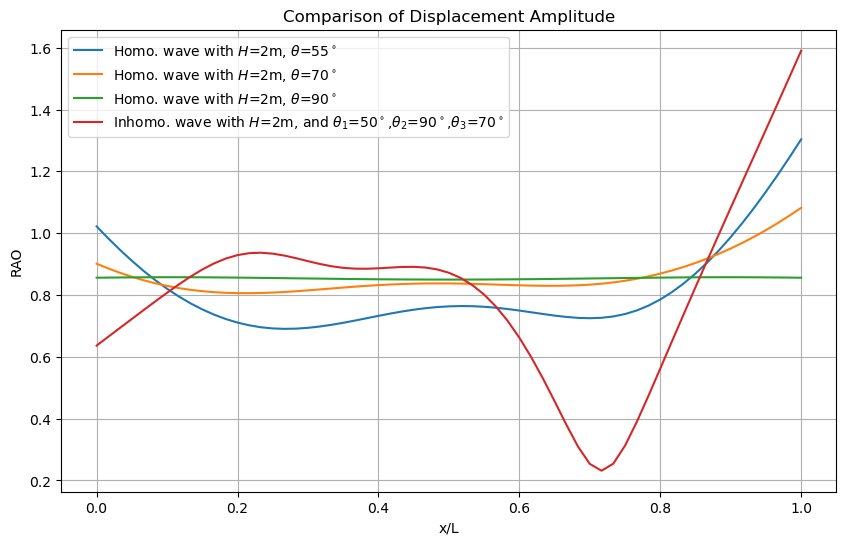

In [10]:
# 绘制对比图
f = 11
x = np.linspace(0, 1, 61)
plt.figure(figsize=(10, 6))
plt.plot(x,abs(reshaped_displacement_55[f,366:427,2]), label=r'Homo. wave with $H$=2m, $\theta$=55$^\circ$')
plt.plot(x,abs(reshaped_displacement_70[f,366:427,2]), label=r'Homo. wave with $H$=2m, $\theta$=70$^\circ$')
plt.plot(x,abs(reshaped_displacement_90[f,366:427,2]), label=r'Homo. wave with $H$=2m, $\theta$=90$^\circ$')
plt.plot(x,abs(reshaped_displacement_combined[f,366:427,2]), label=r'Inhomo. wave with $H$=2m, and $\theta_1$=50$^\circ$,$\theta_2$=90$^\circ$,$\theta_3$=70$^\circ$')
plt.xlabel('x/L')
plt.ylabel('RAO')
plt.title('Comparison of Displacement Amplitude')
plt.legend()
plt.grid(True)
plt.show()

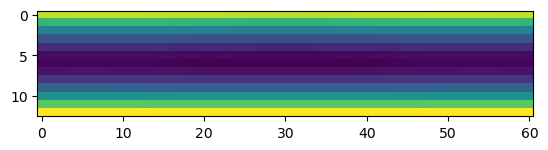

In [11]:
plt.imshow(abs(reshaped_displacement_55[f,:,2]).reshape(13,61), label=r'Homo. wave with $H$=2m, $\theta$=55$^\circ$')
plt.imshow(abs(reshaped_displacement_90[f,:,2]).reshape(13,61))

In [12]:
## 内力计算
import DM_Abaqus_inp as DM_inp
# Example usage
if __name__ == "__main__":
    num_nodes = 793
    degrees_of_freedom = 5
    result_expanded = reshaped_displacement_90[11]  # replace this with your displacenmet matrix
    output_file_path = 'Boundary_Conditions_Job-1.inp'

    DM_inp.main_appied_boundary_conditions(num_nodes, degrees_of_freedom, result_expanded, output_file_path)


Boundary conditions INP file written to Boundary_Conditions_Job-1.inp


### 2.自行设计不均匀海况的算例。

In [13]:
# setting initial parameter, wind and wave conditions
num_nodes = 793 # 63 793
master_nodes = DM_A.calculate_node_positions(424,6,10) #[41, 39, 37, 35, 33, 31, 29, 27, 25, 23] DM_A.calculate_node_positions(425,6,10)
master_nodes_length = len(master_nodes)
dataset_50 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_direction50_full40_uneven.nc"))
dataset_60 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_direction60_full40_uneven.nc"))
dataset_70 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_direction70_full40_uneven.nc"))
dataset_80 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_direction80_full40_uneven.nc"))
dataset_90 = merge_complex_values(xr.open_dataset("E:\phd\Code\DM-FEM2D\HydrodynamicData\Yoga\DM10_direction90_full40_uneven.nc"))

file_m = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_MASS1.mtx'
file_k = 'E:\phd\Code\DM-FEM2D\StructureData\Job-1_55_STIF1.mtx' 
use_hydrostatic = True # select hydrostatic stiffness type(bem or fem)
use_mooring = False 


In [14]:
# 整合波浪激励力
dataset_50['excitation_force'] = dataset_50['Froude_Krylov_force'] + dataset_50['diffraction_force']
dataset_60['excitation_force'] = dataset_60['Froude_Krylov_force'] + dataset_60['diffraction_force']
dataset_70['excitation_force'] = dataset_70['Froude_Krylov_force'] + dataset_70['diffraction_force']
dataset_80['excitation_force'] = dataset_80['Froude_Krylov_force'] + dataset_80['diffraction_force']
dataset_90['excitation_force'] = dataset_90['Froude_Krylov_force'] + dataset_90['diffraction_force']

In [15]:
# 提取相应的部分

part1 = dataset_50['excitation_force'][:, 0, 0:6].values
part2 = dataset_60['excitation_force'][:, 0, 6:12].values
part3 = dataset_70['excitation_force'][:, 0, 12:18].values
part4 = dataset_80['excitation_force'][:, 0, 18:24].values
part5 = dataset_90['excitation_force'][:, 0, 24:30].values
part6 = dataset_90['excitation_force'][:, 0, 30:36].values
part7 = dataset_80['excitation_force'][:, 0, 36:42].values
part8 = dataset_70['excitation_force'][:, 0, 42:48].values
part9 = dataset_60['excitation_force'][:, 0, 48:54].values
part10 = dataset_50['excitation_force'][:, 0, 54:60].values
new_excitation_force = np.concatenate((part1, part2, part3, part4, part5, part6, part7, part8, part9, part10), axis=1).reshape(40,1,60)

#new_excitation_force = np.concatenate((part1, part2, part3), axis=1).reshape(40,1,60)
new_excitation_force_da = xr.DataArray(new_excitation_force, dims=('omega', 'wave_direction','influenced_dof'))
dataset = dataset_60.copy()
dataset['excitation_force'] = new_excitation_force_da

In [16]:

def process_dataset(dataset, omega_number, M, k, num_nodes, master_nodes, use_mooring=False, use_hydrostatic=True, F_wave_coefficient=1.0):
    # reduce dofs
    M_consistant = SEREP.reduce_dofs(M, num_nodes, [5])
    
    if use_mooring:
        k = SEREP.reduce_dofs(k, num_nodes, [5]) + create_mooring_stiffness_matrix(stiffness_value=1e6)
    else:
        k = SEREP.reduce_dofs(k, num_nodes, [5])
    
    # transform mass matrix, beta=0 is consistant mass matrix
    M = SEREP.transform_mass_matrix(M_consistant, beta=0)
    
    # obtain master dofs and slave dofs
    MasterDofs, SlaveDofs = SEREP.separate_dofs(num_nodes, master_nodes)
    
    # reduce matrix use SEREP
    MR, KR, T = SEREP.SEREP(k, M, SlaveDofs, master_nodes)
    
    displacement = []
    F_wave = []
    mass_full = []
    damping_full = []
    stiffness_full = []
    
    for i in omega_number:
        # read hydrodynamic data
        added_mass = dataset['added_mass'][i].values
        radiation_damping = dataset['radiation_damping'][i].values
        F_w = dataset['excitation_force'][i].values
        
        # reduce matrices
        added_mass = SEREP.reduce_dofs(added_mass, len(master_nodes), [5])
        radiation_damping = SEREP.reduce_dofs(radiation_damping, len(master_nodes), [5])
        
        if use_hydrostatic:
            hydrostatic_stiffness = SEREP.reduce_dofs(dataset['hydrostatic_stiffness'].values, len(master_nodes), [5])
            stiffness = hydrostatic_stiffness/0.98 + KR
        else:
            total_nodes = 793
            nodes_per_row = 61
            area = 5 * 5
            k_fem = SEREP.get_fem_spring_stiffness(total_nodes, nodes_per_row, area)
            k_fem = SEREP.reduce_dofs(k_fem, num_nodes, [5])
            stiffness = T.T @ k_fem @ T + KR
        
        F_w = SEREP.reduce_force_matrix_dofs(F_w, len(master_nodes), 5).reshape(1, 5 * len(master_nodes))
        
        # generate the system matrices
        mass = added_mass + MR
        damping = radiation_damping
        total_force = F_w * F_wave_coefficient
        
        # solve in frequency domain
        master_displacement = DM_A.solve_frequency_domain(mass, damping, stiffness, total_force, omega[i])
        
        # restore global displacement under disorder masterdofs and slavedofs
        global_displacement_disorder = T @ master_displacement
        
        # reorder global displacement under order
        global_displacement = SEREP.reorder_displacement_matrix(global_displacement_disorder, MasterDofs, SlaveDofs)
        
        # replace master with global displacement
        global_displacement_replace = DM_M.replace_master_with_global(master_displacement, global_displacement, master_nodes)
        
        # save data
        displacement.append(global_displacement_replace)
        F_wave.append(F_w)
        mass_full.append(mass)
        damping_full.append(damping)
        stiffness_full.append(stiffness)
    
    return {
        'displacement': displacement,
        'F_wave': F_wave,
        'mass_full': mass_full,
        'damping_full': damping_full,
        'stiffness_full': stiffness_full
    }

# 主程序
omega = dataset_60.omega.values
omega_number = np.arange(0, 40, 1)

# 读取质量和刚度矩阵
M = dm_r.get_stiffness_matrix(file_m)
k = dm_r.get_stiffness_matrix(file_k)

# 参数
num_nodes = 793
master_nodes = master_nodes = DM_A.calculate_node_positions(424,6,10)  # 示例主自由度节点
use_mooring = False
use_hydrostatic = True
F_wave_coefficient = 1.0

# 处理每个数据集
results_50 = process_dataset(dataset_50, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_60 = process_dataset(dataset_60, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_70 = process_dataset(dataset_70, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_80 = process_dataset(dataset_80, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_90 = process_dataset(dataset_90, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)
results_combined = process_dataset(dataset, omega_number, M, k, num_nodes, master_nodes, use_mooring, use_hydrostatic, F_wave_coefficient)

In [17]:
import scienceplots
plt.style.use(['science','no-latex','ieee'])

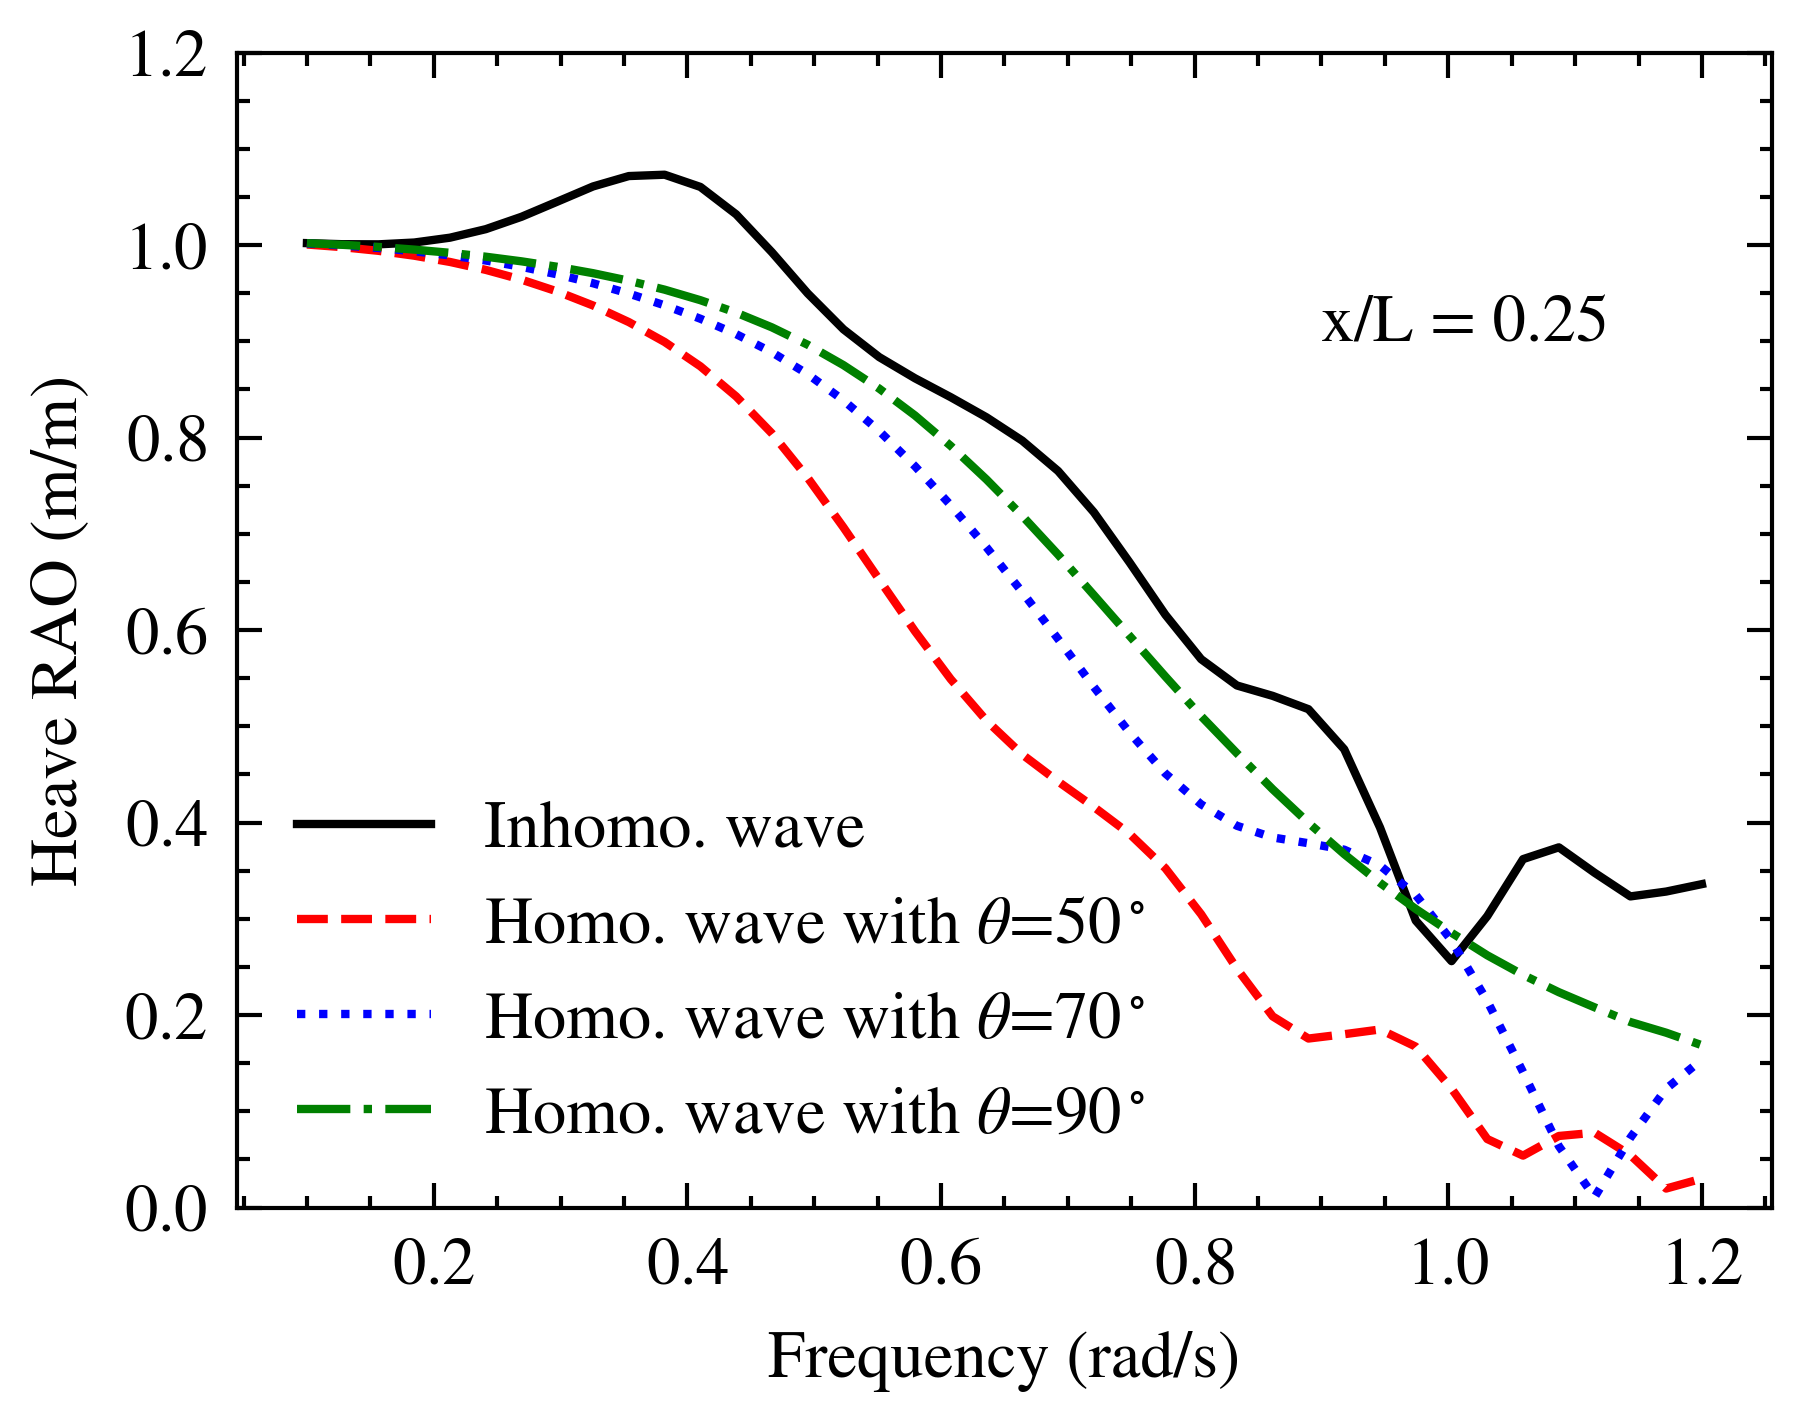

In [18]:
# 转换 displacement 数据结构为 (40, 793, 5)
def reshape_displacement(displacement):
    num_omega, num_values, _ = displacement.shape
    num_nodes = 793
    dofs_per_node = 5
    reshaped_displacement = displacement.reshape(num_omega, num_nodes, dofs_per_node)
    return reshaped_displacement

# 获取数据
displacement_50 = np.array(results_50['displacement'])  # 新增 Dataset 50 的数据
displacement_60 = np.array(results_60['displacement'])
displacement_70 = np.array(results_70['displacement'])
displacement_80 = np.array(results_80['displacement'])
displacement_90 = np.array(results_90['displacement'])
displacement_combined = np.array(results_combined['displacement'])

# 重新调整数据结构
reshaped_displacement_50 = reshape_displacement(displacement_50)  # 新增 Dataset 50 的数据
reshaped_displacement_60 = reshape_displacement(displacement_60)
reshaped_displacement_70 = reshape_displacement(displacement_70)
reshaped_displacement_80 = reshape_displacement(displacement_80)
reshaped_displacement_90 = reshape_displacement(displacement_90)
reshaped_displacement_combined = reshape_displacement(displacement_combined)

# 数据集列表
# 数据集列表，包含每个数据集的名称和对应的数据
datasets = {
    'Inhomo. wave': reshaped_displacement_combined,
    r'Homo. wave with $\theta$=50$^\circ$': reshaped_displacement_50,  # 新增 Dataset 50
    #'Dataset 60': reshaped_displacement_60,
    r'Homo. wave with $\theta$=70$^\circ$': reshaped_displacement_70,
    #'Dataset 80': reshaped_displacement_80,
    r'Homo. wave with $\theta$=90$^\circ$': reshaped_displacement_90
}


# 绘制对比图
n = 382  # 指定节点编号 366 382
DOF = 2  # 指定自由度
#plt.figure(figsize=(10, 6))

for key, reshaped_data in datasets.items():
    plt.plot(omega, abs(reshaped_data[:, n, DOF]), label=f'{key}')

plt.text(0.9, 0.9, 'x/L = 0.25', fontsize=8, color='black')
plt.xlabel(r'Frequency (rad/s)')
plt.ylabel('Heave RAO (m/m)')
#plt.title('Comparison of Displacement Amplitude')
plt.legend()
plt.ylim(0,1.2)
plt.savefig("Unevenwave_xl025.pdf", format='pdf', dpi=300) 
#plt.grid(True)
plt.show()


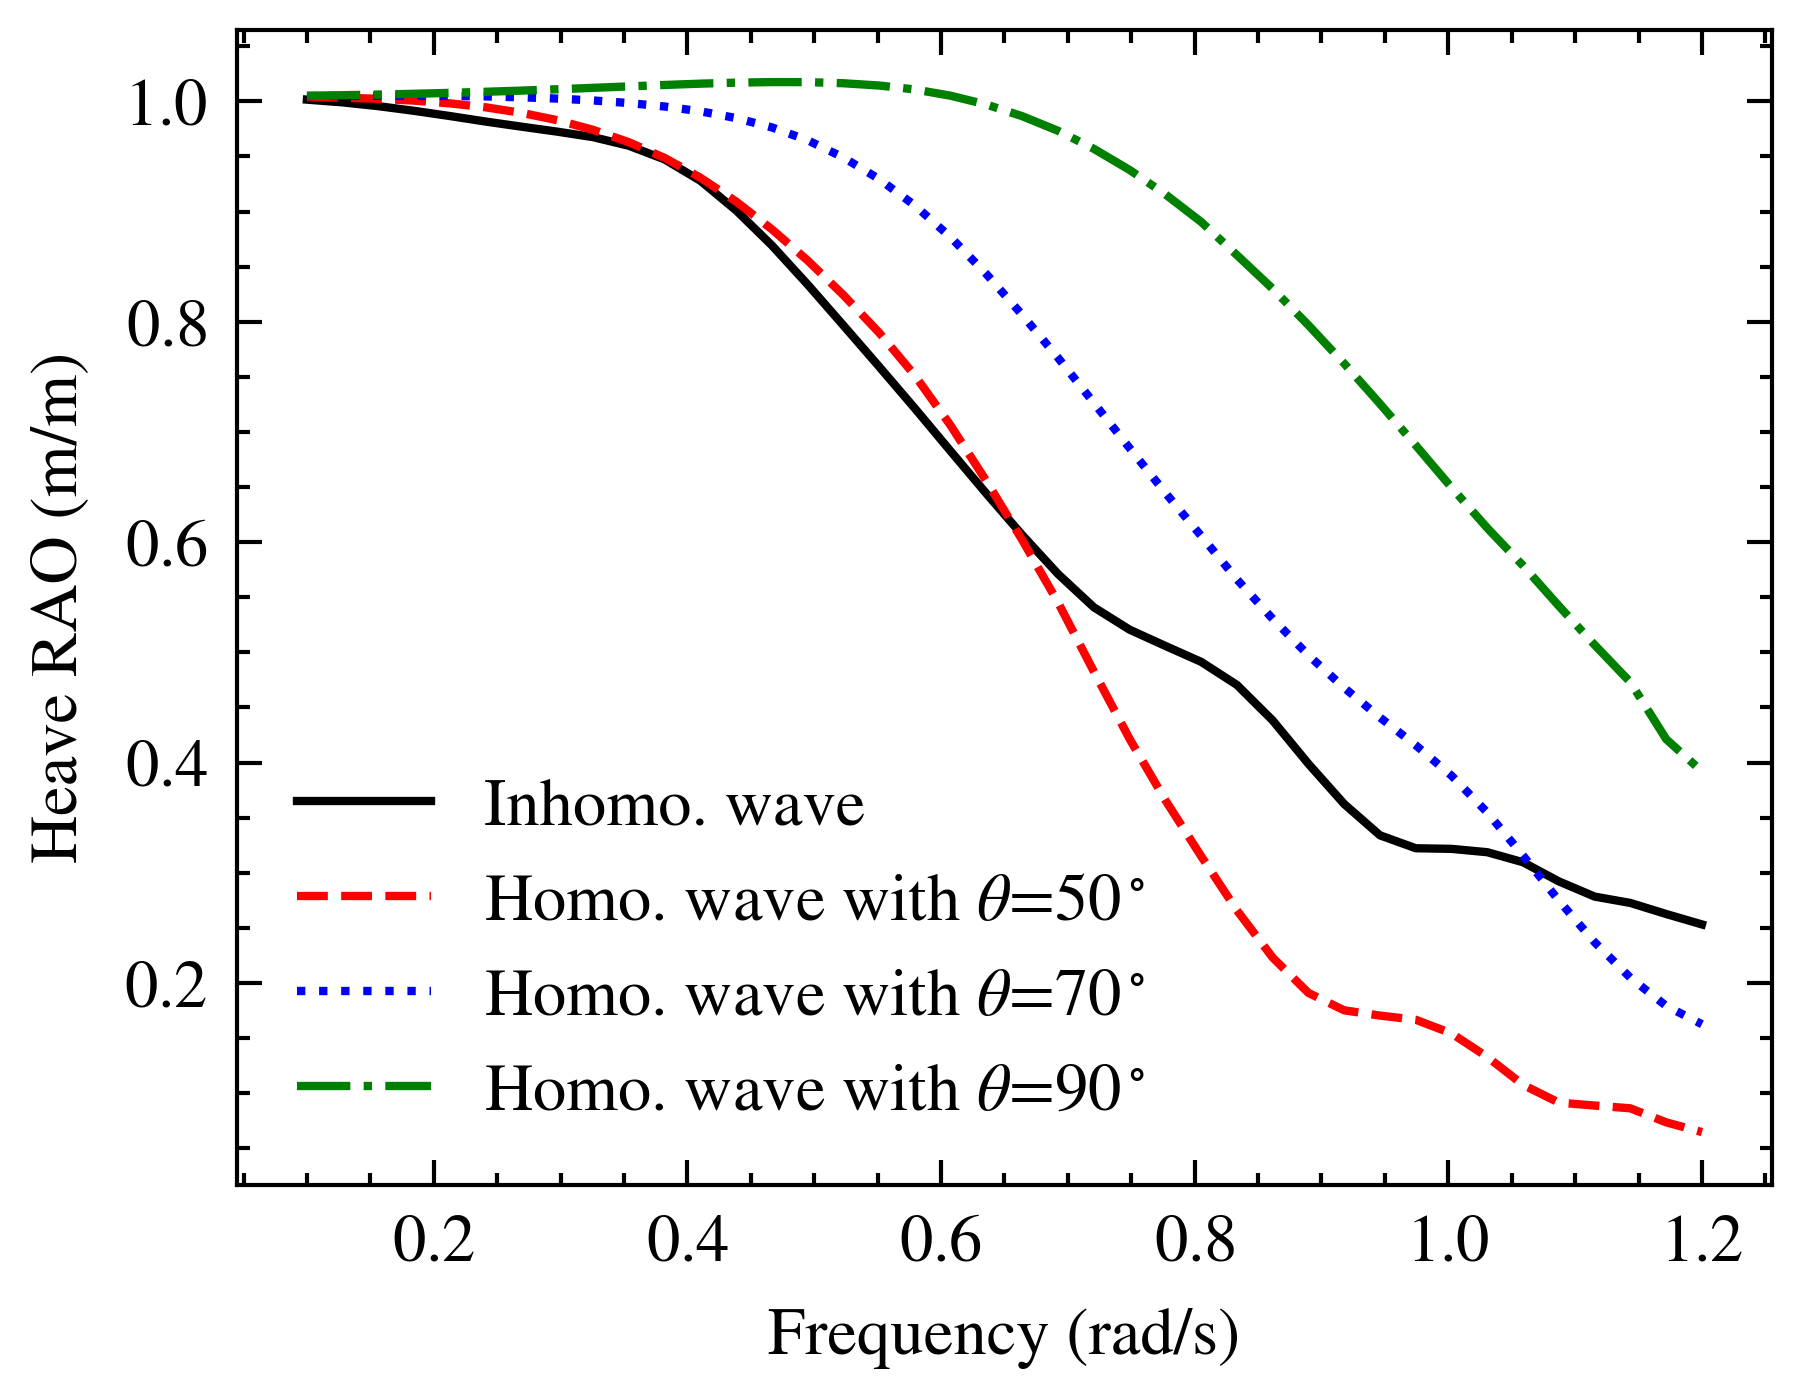

In [19]:
# 绘制对比图

#plt.figure(figsize=(10, 6))

# 数据集列表，包含每个数据集的名称和对应的数据
datasets = {
    'Inhomo. wave': reshaped_displacement_combined,
    r'Homo. wave with $\theta$=50$^\circ$': reshaped_displacement_50,  # 新增 Dataset 50
    #'Dataset 60': reshaped_displacement_60,
    r'Homo. wave with $\theta$=70$^\circ$': reshaped_displacement_70,
    #'Dataset 80': reshaped_displacement_80,
    r'Homo. wave with $\theta$=90$^\circ$': reshaped_displacement_90
}

# 遍历数据集并绘图
for label, data in datasets.items():
    # 计算每个频率下所有节点（793节点）在指定自由度上的平均幅值
    mean_amplitude = abs(data[:, :, 2]).mean(axis=1)
    plt.plot(omega, mean_amplitude, label=label)

plt.xlabel(r'Frequency (rad/s)')
plt.ylabel('Heave RAO (m/m)')
#plt.title('Comparison of Displacement Amplitude')
plt.legend()
plt.savefig("Unevenwave_mean.pdf", format='pdf', dpi=300) 
#plt.grid(True)
plt.show()


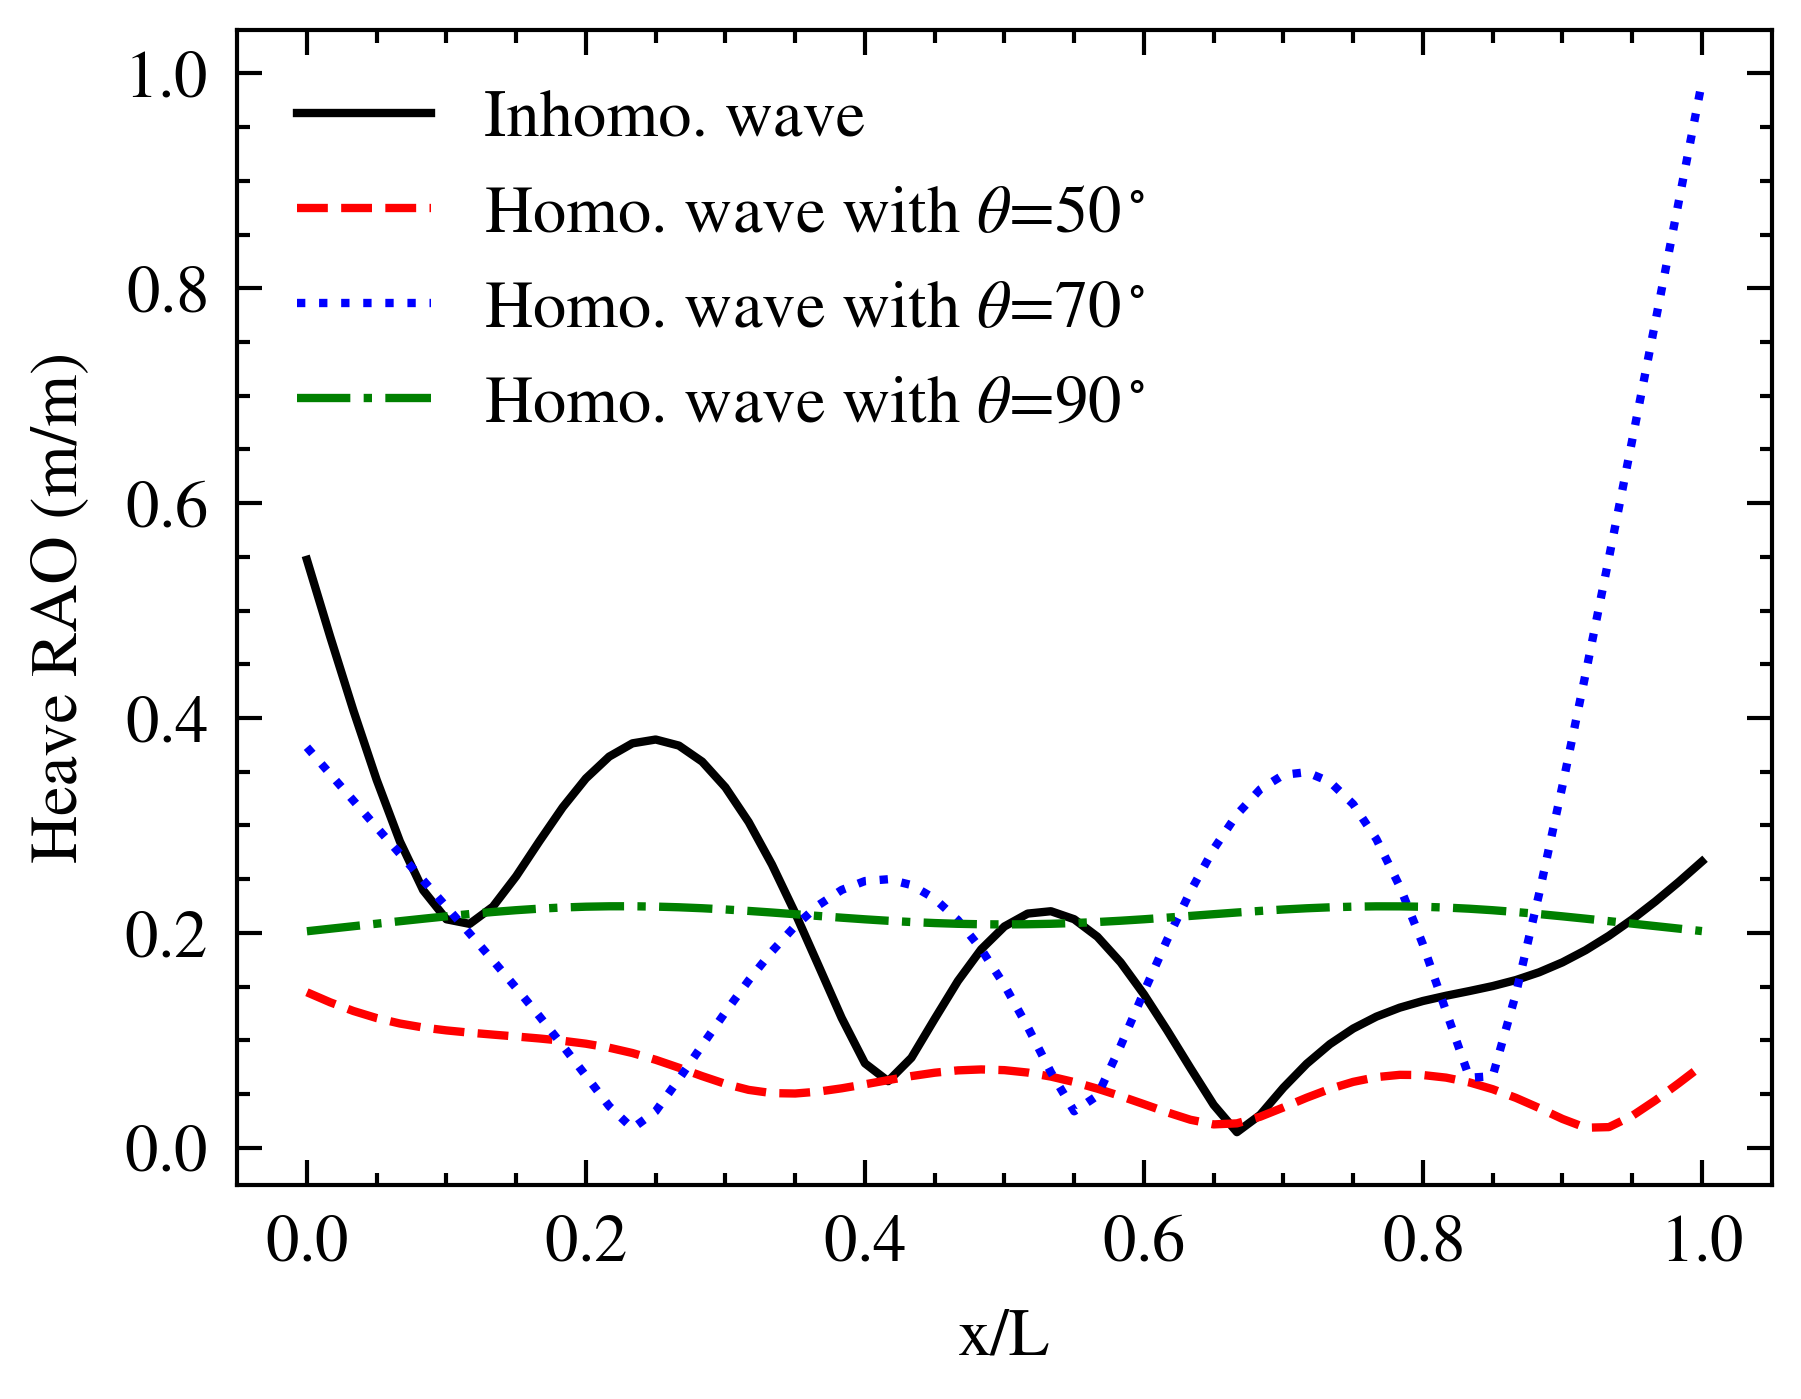

In [20]:
# 绘制对比图
f = 35  # 频率索引 6 15 25 35
x = np.linspace(0, 1, 61)  # x/L 坐标
# plt.figure(figsize=(10, 6))

# 绘制各数据集的结果
plt.plot(x, abs(reshaped_displacement_combined[f, 366:427, 2]), 
         label=r'Inhomo. wave')
plt.plot(x, abs(reshaped_displacement_50[f, 366:427, 2]), 
         label=r'Homo. wave with $\theta$=50$^\circ$')
# plt.plot(x, abs(reshaped_displacement_60[f, 366:427, 2]), 
#          label=r'Homo. wave with $H$=2m, $\theta$=60$^\circ$')
plt.plot(x, abs(reshaped_displacement_70[f, 366:427, 2]), 
         label=r'Homo. wave with $\theta$=70$^\circ$')
# plt.plot(x, abs(reshaped_displacement_80[f, 366:427, 2]), 
#          label=r'Homo. wave with $H$=2m, $\theta$=80$^\circ$')
plt.plot(x, abs(reshaped_displacement_90[f, 366:427, 2]), 
         label=r'Homo. wave with $\theta$=90$^\circ$')


# 设置标签和标题
plt.xlabel('x/L')
plt.ylabel('Heave RAO (m/m)')
# plt.ylim(0,1.5)
plt.legend()
plt.savefig("Unevenwave_fre108.pdf", format='pdf', dpi=300) 
plt.show()


In [24]:
## 内力计算
import DM_Abaqus_inp as DM_inp
# Example usage
if __name__ == "__main__":
    num_nodes = 793
    degrees_of_freedom = 5
    f = 35  # 频率索引 6 15 25 35
    result_expanded = reshaped_displacement_90[f, :, :]
    #result_expanded = np.sqrt(wind_displacement_root_mean_square) # replace this with your displacenmet matrix
    output_file_path = 'Boundary_Conditions_Job-1.inp'

    DM_inp.main_appied_boundary_conditions(num_nodes, degrees_of_freedom, result_expanded, output_file_path)
    input_new = 'Boundary_Conditions_Job-1_3_6.inp'
    DM_inp.modify_inp_file(output_file_path, input_new)

Boundary conditions INP file written to Boundary_Conditions_Job-1.inp
